# 🎨 DermaAI - Mejora de Imágenes con IA

Este notebook entrena un modelo U-Net para:
- **Segmentación** de lesiones cutáneas
- **Eliminación de sombras** y artefactos
- **Mejora de contraste** para mejor diagnóstico

---

## 1. Configuración del Entorno

In [1]:
# Instalar dependencias
!pip install kagglehub opencv-python-headless scikit-image -q

import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from skimage import filters, morphology, exposure
from glob import glob
import random

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU disponible: []


## 2. Descarga del Dataset ISIC

In [2]:
import kagglehub

# Descargar el dataset de Kaggle
path = kagglehub.dataset_download("rajivaiml/isic-skin-cancer-dataset")
print(f"📁 Dataset descargado en: {path}")

# Encontrar la ruta correcta
base_path = None
for root, dirs, files in os.walk(path):
    if 'Train' in dirs and 'Test' in dirs:
        base_path = root
        break

if base_path is None:
    base_path = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")

TRAIN_DIR = os.path.join(base_path, "Train")
TEST_DIR = os.path.join(base_path, "Test")

print(f"✅ Train: {TRAIN_DIR}")
print(f"✅ Test: {TEST_DIR}")

# Listar clases
classes = sorted(os.listdir(TRAIN_DIR))
print(f"\n📊 Clases: {classes}")

Using Colab cache for faster access to the 'isic-skin-cancer-dataset' dataset.
📁 Dataset descargado en: /kaggle/input/isic-skin-cancer-dataset
✅ Train: /kaggle/input/isic-skin-cancer-dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train
✅ Test: /kaggle/input/isic-skin-cancer-dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test

📊 Clases: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


## 3. Configuración de Hiperparámetros

In [3]:
# ============================================
# CONFIGURACIÓN
# ============================================

IMG_SIZE = 128  # Tamaño para U-Net (más pequeño para entrenamiento más rápido)
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.001

print(f"📊 Configuración:")
print(f"   Tamaño de imagen: {IMG_SIZE}x{IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Épocas: {EPOCHS}")

📊 Configuración:
   Tamaño de imagen: 128x128
   Batch size: 16
   Épocas: 20


## 4. Funciones de Preprocesamiento y Generación de Máscaras

In [4]:
def load_image(path, size=IMG_SIZE):
    """Carga y redimensiona una imagen."""
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (size, size))
    return img


def generate_mask_otsu(img):
    """
    Genera una máscara de segmentación usando Otsu thresholding.
    Esta es una aproximación semi-automática para crear datos de entrenamiento.
    """
    # Convertir a escala de grises
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Aplicar blur para reducir ruido
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Aplicar Otsu thresholding
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Operaciones morfológicas para limpiar
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    
    # Encontrar el contorno más grande (asumimos que es la lesión)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(mask)
        cv2.drawContours(mask, [largest_contour], -1, 255, -1)
    
    return mask / 255.0  # Normalizar a [0, 1]


def remove_shadows(img):
    """
    Elimina sombras usando filtrado homomórfico.
    """
    # Convertir a float y aplicar log
    img_float = img.astype(np.float64) + 1
    img_log = np.log(img_float)
    
    # Aplicar filtro Gaussiano en cada canal
    result = np.zeros_like(img_float)
    for i in range(3):
        # Filtro de paso alto
        low_freq = cv2.GaussianBlur(img_log[:,:,i], (21, 21), 0)
        high_freq = img_log[:,:,i] - low_freq
        # Reconstruir
        result[:,:,i] = np.exp(high_freq + np.mean(low_freq))
    
    # Normalizar y convertir a uint8
    result = np.clip(result, 0, 255).astype(np.uint8)
    return result


def enhance_image(img):
    """
    Pipeline completo de mejora de imagen.
    """
    # 1. Eliminar sombras
    img_no_shadows = remove_shadows(img)
    
    # 2. Aplicar CLAHE para mejorar contraste
    lab = cv2.cvtColor(img_no_shadows, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    lab[:,:,0] = clahe.apply(lab[:,:,0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    return enhanced


print("✅ Funciones de preprocesamiento definidas")

✅ Funciones de preprocesamiento definidas


## 5. Preparar Datos de Entrenamiento

In [5]:
# Recolectar todas las imágenes
all_images = []
for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        images = glob(os.path.join(class_path, "*.jpg"))
        all_images.extend(images[:50])  # Limitar para entrenamiento rápido

print(f"📊 Total de imágenes: {len(all_images)}")

# Mezclar
random.shuffle(all_images)

# Cargar imágenes y generar máscaras
X = []  # Imágenes
Y = []  # Máscaras

print("\n🔄 Cargando imágenes y generando máscaras...")
for i, img_path in enumerate(all_images):
    try:
        img = load_image(img_path)
        mask = generate_mask_otsu(img)
        
        X.append(img / 255.0)  # Normalizar a [0, 1]
        Y.append(mask)
        
        if (i + 1) % 100 == 0:
            print(f"   Procesadas {i+1}/{len(all_images)} imágenes")
    except Exception as e:
        print(f"   Error con {img_path}: {e}")

X = np.array(X)
Y = np.array(Y)
Y = np.expand_dims(Y, axis=-1)  # Añadir canal

print(f"\n✅ Datos preparados:")
print(f"   X shape: {X.shape}")
print(f"   Y shape: {Y.shape}")

# Dividir en train/val
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"\n   Train: {X_train.shape[0]} imágenes")
print(f"   Val: {X_val.shape[0]} imágenes")

📊 Total de imágenes: 450

🔄 Cargando imágenes y generando máscaras...
   Procesadas 100/450 imágenes
   Procesadas 200/450 imágenes
   Procesadas 300/450 imágenes
   Procesadas 400/450 imágenes

✅ Datos preparados:
   X shape: (450, 128, 128, 3)
   Y shape: (450, 128, 128, 1)

   Train: 360 imágenes
   Val: 90 imágenes


## 6. Visualizar Ejemplos

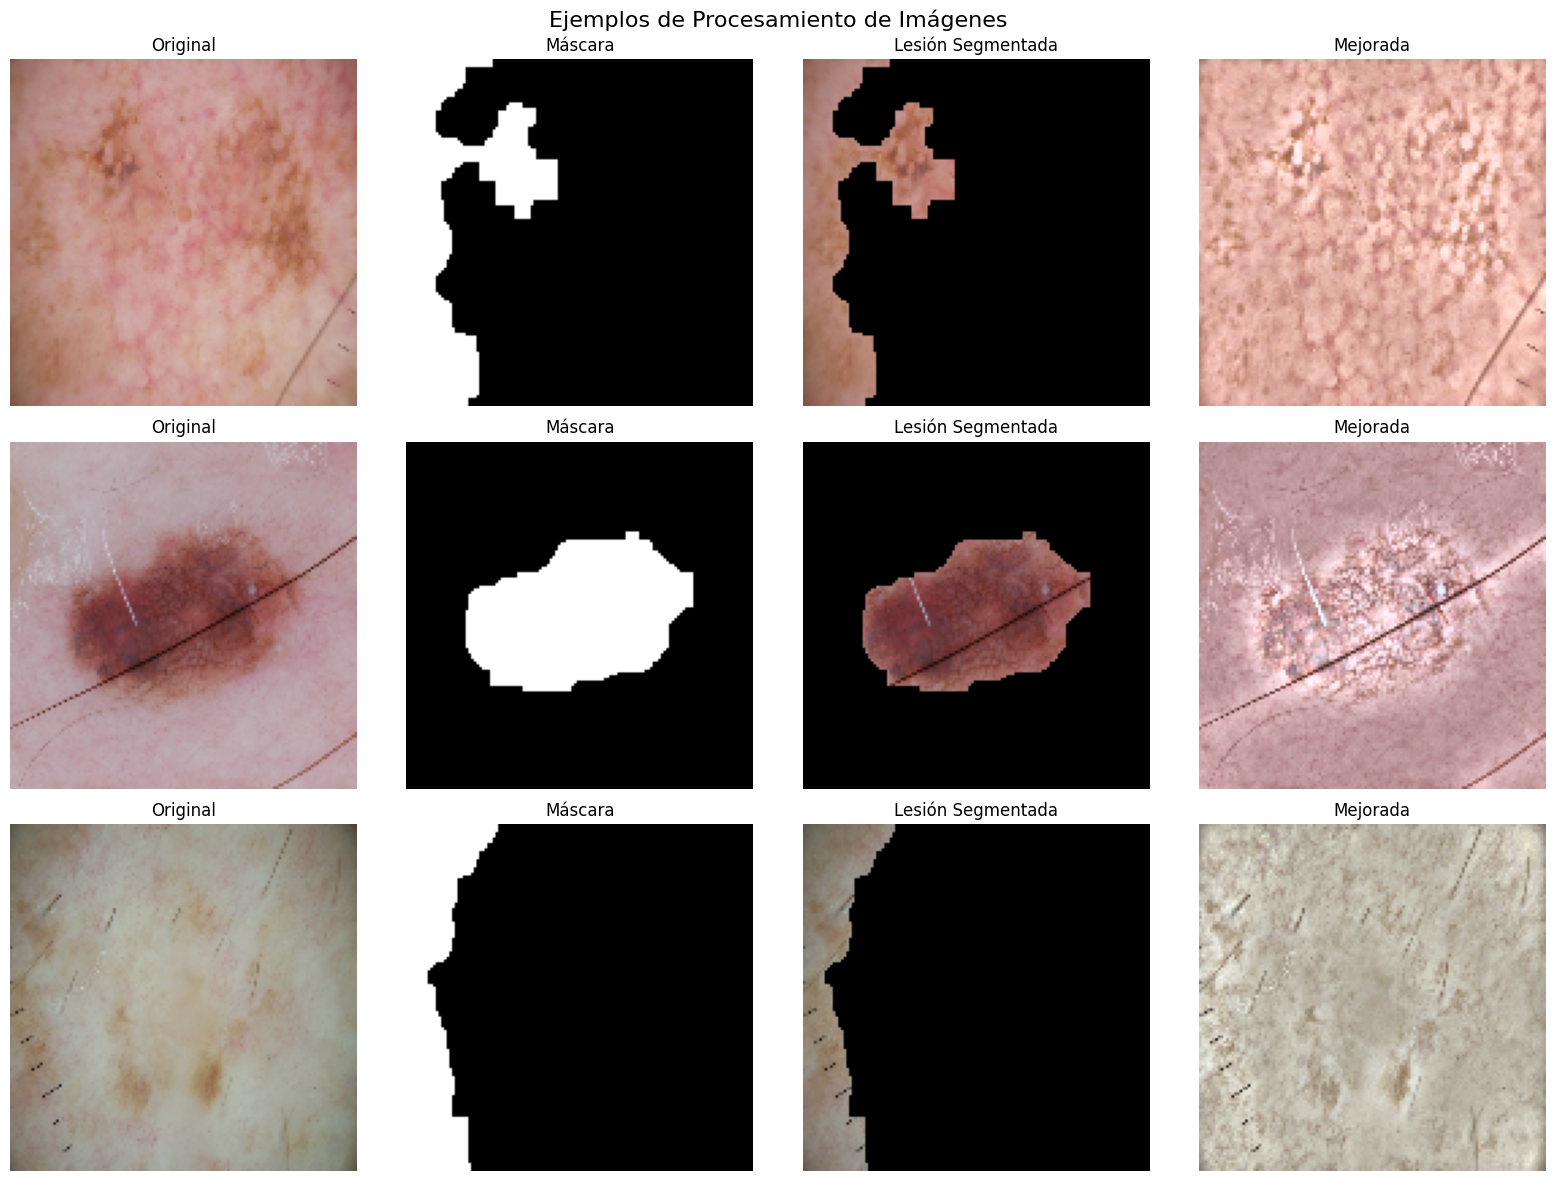

In [6]:
# Visualizar algunos ejemplos
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i in range(3):
    idx = random.randint(0, len(X_train) - 1)
    
    # Imagen original
    axes[i, 0].imshow(X_train[idx])
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')
    
    # Máscara
    axes[i, 1].imshow(Y_train[idx].squeeze(), cmap='gray')
    axes[i, 1].set_title('Máscara')
    axes[i, 1].axis('off')
    
    # Imagen con máscara aplicada
    masked = X_train[idx] * Y_train[idx]
    axes[i, 2].imshow(masked)
    axes[i, 2].set_title('Lesión Segmentada')
    axes[i, 2].axis('off')
    
    # Imagen mejorada
    enhanced = enhance_image((X_train[idx] * 255).astype(np.uint8))
    axes[i, 3].imshow(enhanced)
    axes[i, 3].set_title('Mejorada')
    axes[i, 3].axis('off')

plt.suptitle('Ejemplos de Procesamiento de Imágenes', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Definir Modelo U-Net

In [7]:
def conv_block(inputs, filters, kernel_size=3):
    """Bloque de convolución: Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU"""
    x = layers.Conv2D(filters, kernel_size, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def encoder_block(inputs, filters):
    """Bloque del encoder: Conv Block -> MaxPool"""
    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p


def decoder_block(inputs, skip, filters):
    """Bloque del decoder: UpSample -> Concat -> Conv Block"""
    x = layers.UpSampling2D((2, 2))(inputs)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """
    Construye el modelo U-Net para segmentación de imágenes.
    """
    inputs = layers.Input(shape=input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)
    s4, p4 = encoder_block(p3, 256)
    
    # Bottleneck
    b = conv_block(p4, 512)
    
    # Decoder
    d1 = decoder_block(b, s4, 256)
    d2 = decoder_block(d1, s3, 128)
    d3 = decoder_block(d2, s2, 64)
    d4 = decoder_block(d3, s1, 32)
    
    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d4)
    
    model = models.Model(inputs, outputs, name='U-Net')
    return model


# Crear modelo
model = build_unet()

# Mostrar resumen
model.summary()

print(f"\n📊 Parámetros totales: {model.count_params():,}")

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 7,858,433 (29.98 MB)

 Trainable params: 7,852,545 (29.96 MB)

 Non-trainable params: 5,888 (23.00 KB)


📊 Parámetros totales: 7,858,433


## 8. Compilar y Entrenar el Modelo

In [8]:
# Definir métricas
def dice_coef(y_true, y_pred, smooth=1):
    """Coeficiente Dice para medir similitud de máscaras."""
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    """Pérdida Dice."""
    return 1 - dice_coef(y_true, y_pred)


# Compilar modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coef]
)

# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_dice_coef',
        patience=5,
        mode='max',
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

print("✅ Modelo compilado!")

✅ Modelo compilado!


In [9]:
# Entrenar modelo
print("🚀 Iniciando entrenamiento...\n")

history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)

print("\n✅ Entrenamiento completado!")

🚀 Iniciando entrenamiento...

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 286s 12s/step - accuracy: 0.7445 - dice_coef: 0.4700 - loss: 0.5314 - val_accuracy: 0.2479 - val_dice_coef: 0.3951 - val_loss: 97.2771 - learning_rate: 0.0010
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 257s 11s/step - accuracy: 0.8663 - dice_coef: 0.5802 - loss: 0.3354 - val_accuracy: 0.6438 - val_dice_coef: 0.4228 - val_loss: 1.5219 - learning_rate: 0.0010
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 255s 11s/step - accuracy: 0.8732 - dice_coef: 0.5823 - loss: 0.3128 - val_accuracy: 0.4120 - val_dice_coef: 0.4434 - val_loss: 2.2320 - learning_rate: 0.0010
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 262s 11s/step - accuracy: 0.8829 - dice_coef: 0.6182 - loss: 0.2771 - val_accuracy: 0.3548 - val_dice_coef: 0.4201 - val_loss: 8.2760 - learning_rate: 0.0010
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 256s 11s/step - accuracy: 0.8904 - dice_coef: 0.6483 - loss: 0.2721 - val_accuracy: 0.4949 - val_dice_coef: 0.4669 - val_loss: 2.8564 - learning_ra

## 9. Visualizar Resultados del Entrenamiento

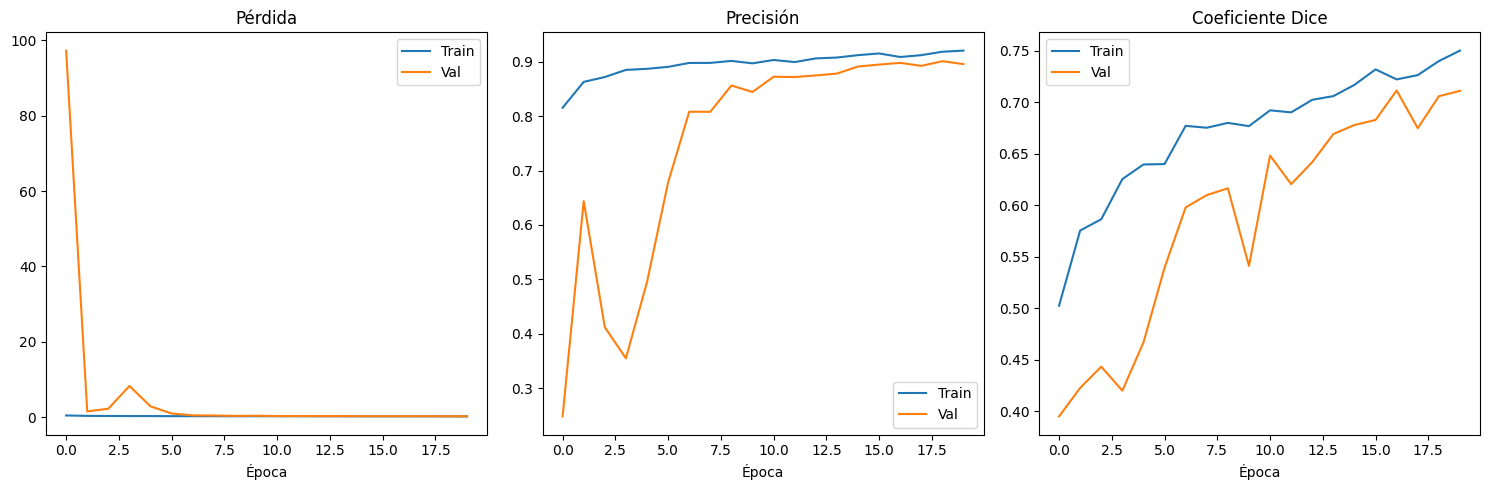

In [10]:
# Graficar historial
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Pérdida')
axes[0].set_xlabel('Época')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Precisión')
axes[1].set_xlabel('Época')
axes[1].legend()

# Dice
axes[2].plot(history.history['dice_coef'], label='Train')
axes[2].plot(history.history['val_dice_coef'], label='Val')
axes[2].set_title('Coeficiente Dice')
axes[2].set_xlabel('Época')
axes[2].legend()

plt.tight_layout()
plt.show()

## 10. Visualizar Predicciones

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


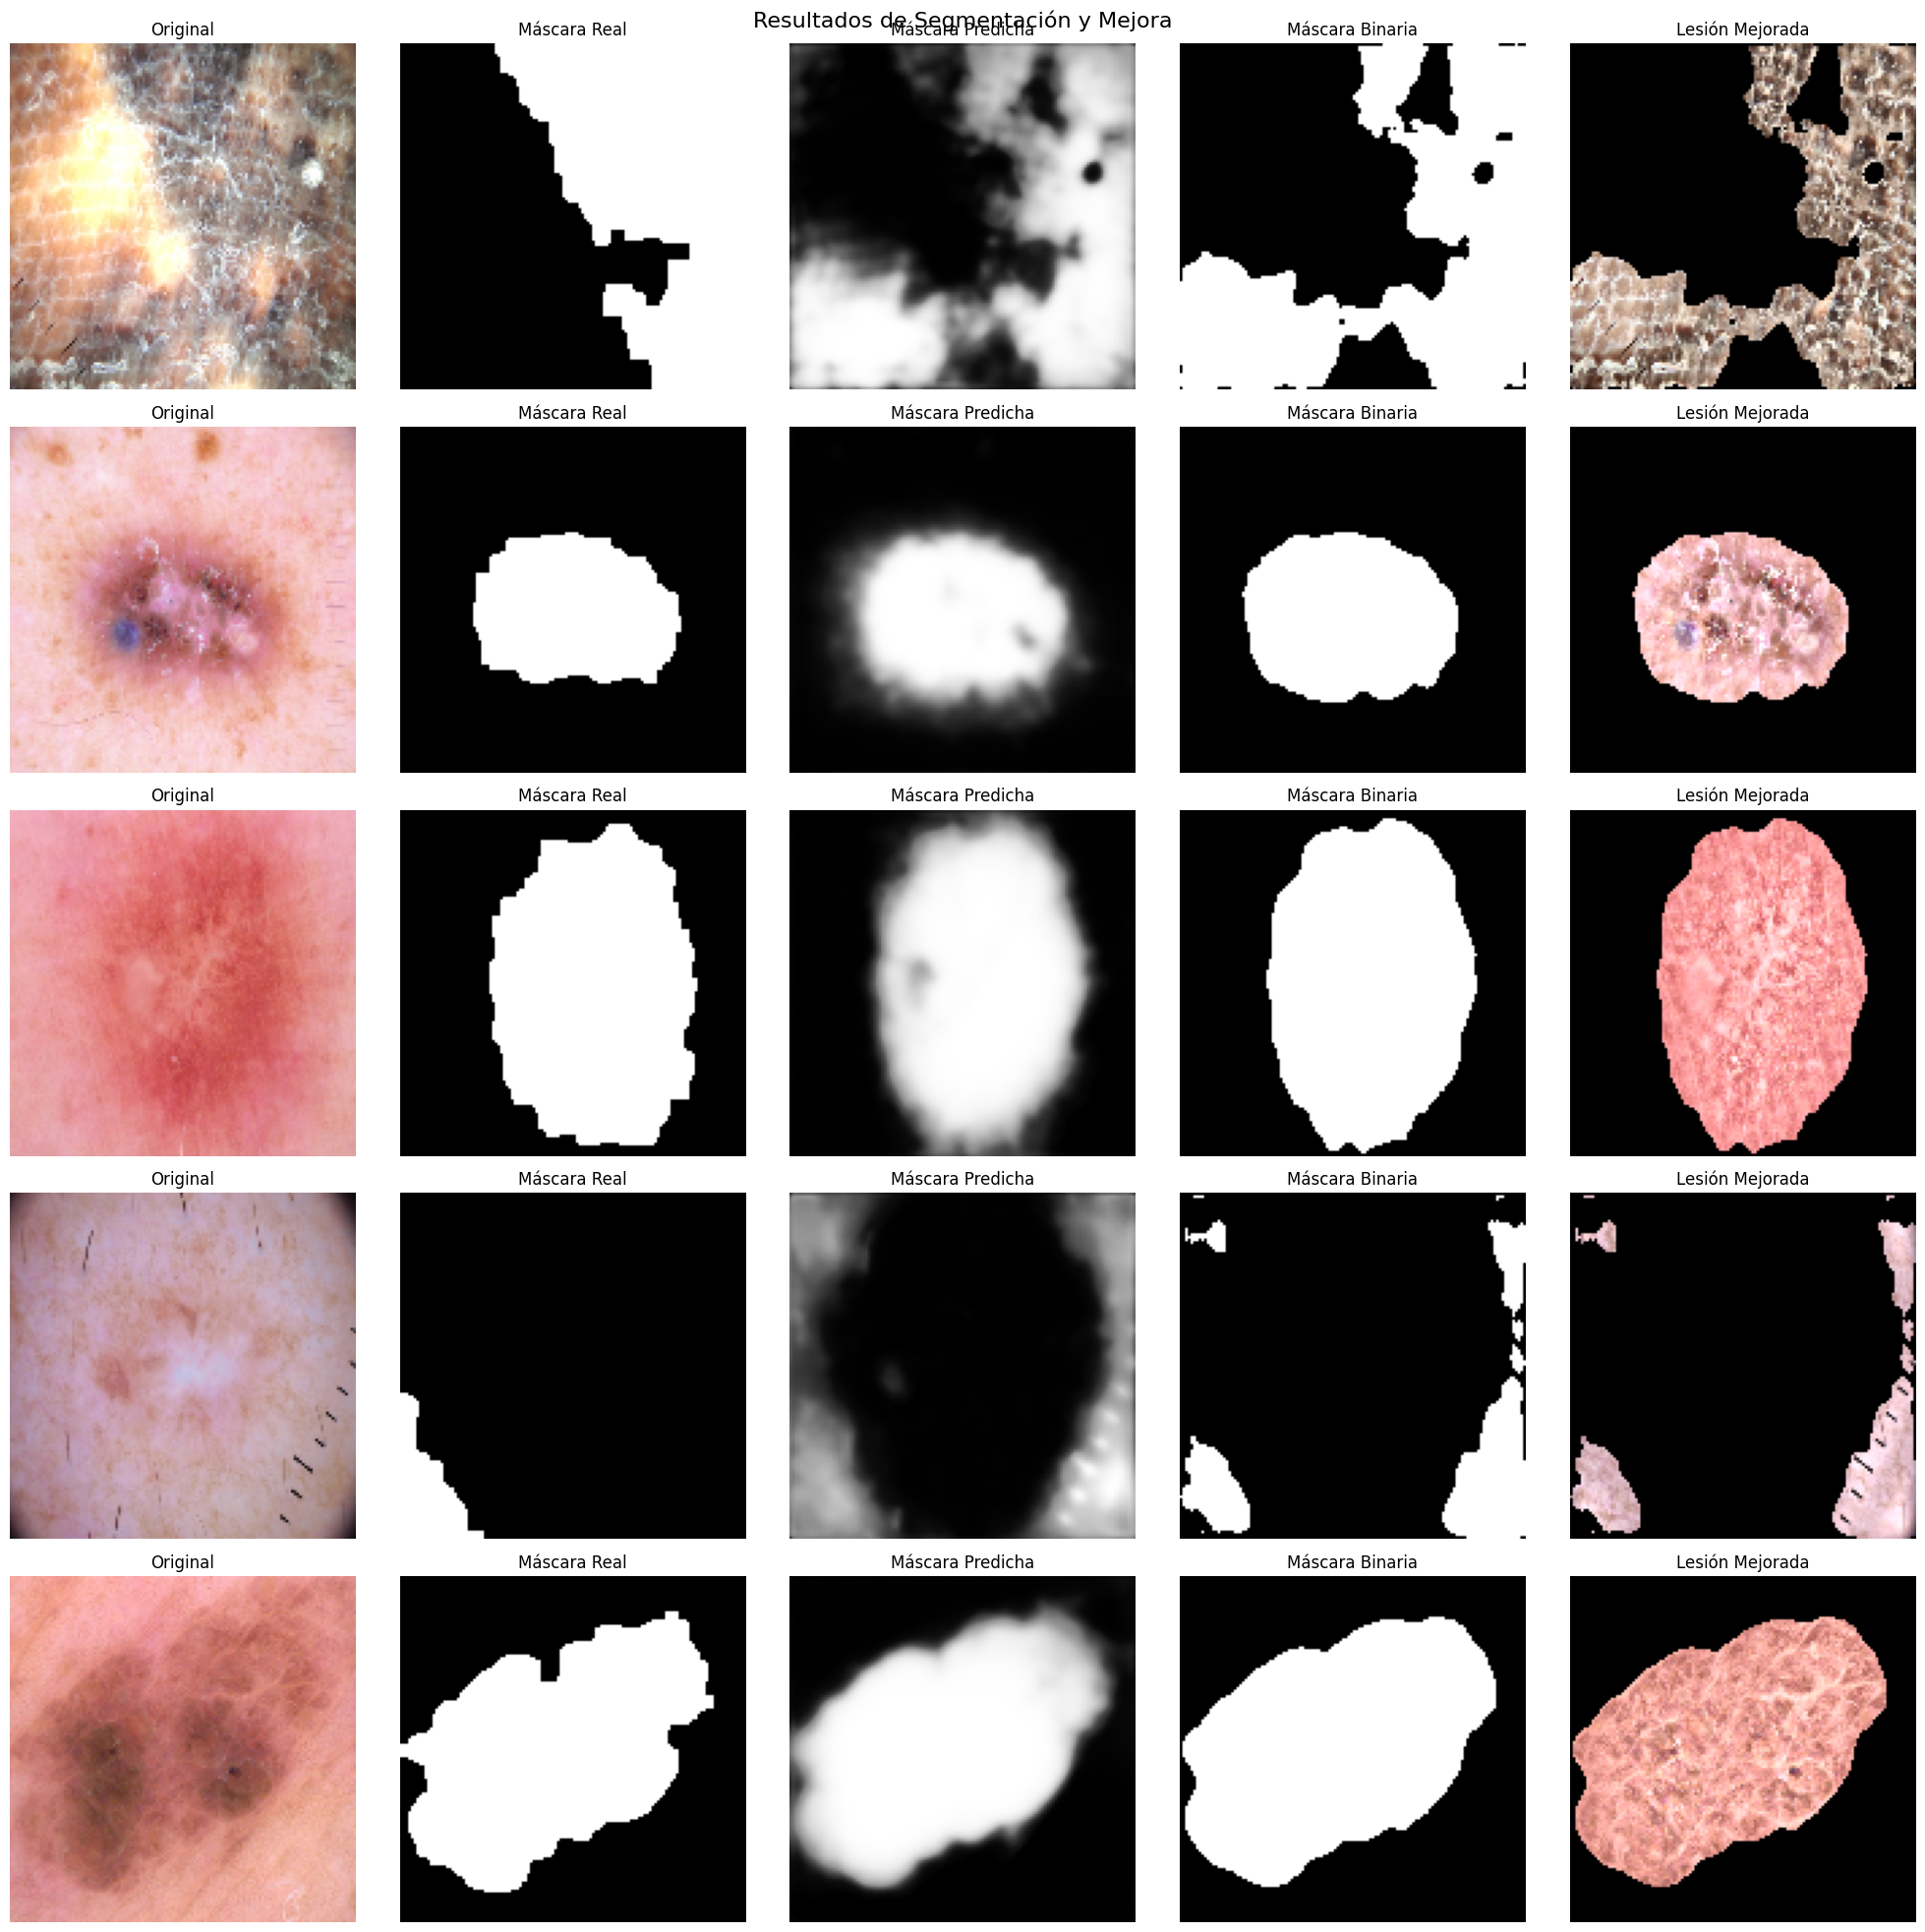

In [11]:
# Predicciones en validación
predictions = model.predict(X_val[:10])

# Visualizar
fig, axes = plt.subplots(5, 5, figsize=(20, 20))

for i in range(5):
    # Original
    axes[i, 0].imshow(X_val[i])
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')
    
    # Máscara real
    axes[i, 1].imshow(Y_val[i].squeeze(), cmap='gray')
    axes[i, 1].set_title('Máscara Real')
    axes[i, 1].axis('off')
    
    # Máscara predicha
    axes[i, 2].imshow(predictions[i].squeeze(), cmap='gray')
    axes[i, 2].set_title('Máscara Predicha')
    axes[i, 2].axis('off')
    
    # Máscara predicha umbralizada
    mask_binary = (predictions[i].squeeze() > 0.5).astype(np.float32)
    axes[i, 3].imshow(mask_binary, cmap='gray')
    axes[i, 3].set_title('Máscara Binaria')
    axes[i, 3].axis('off')
    
    # Lesión segmentada con mejora
    img_enhanced = enhance_image((X_val[i] * 255).astype(np.uint8))
    masked = (img_enhanced / 255.0) * np.expand_dims(mask_binary, axis=-1)
    axes[i, 4].imshow(masked)
    axes[i, 4].set_title('Lesión Mejorada')
    axes[i, 4].axis('off')

plt.suptitle('Resultados de Segmentación y Mejora', fontsize=16)
plt.tight_layout()
plt.show()

## 11. Función de Mejora Completa

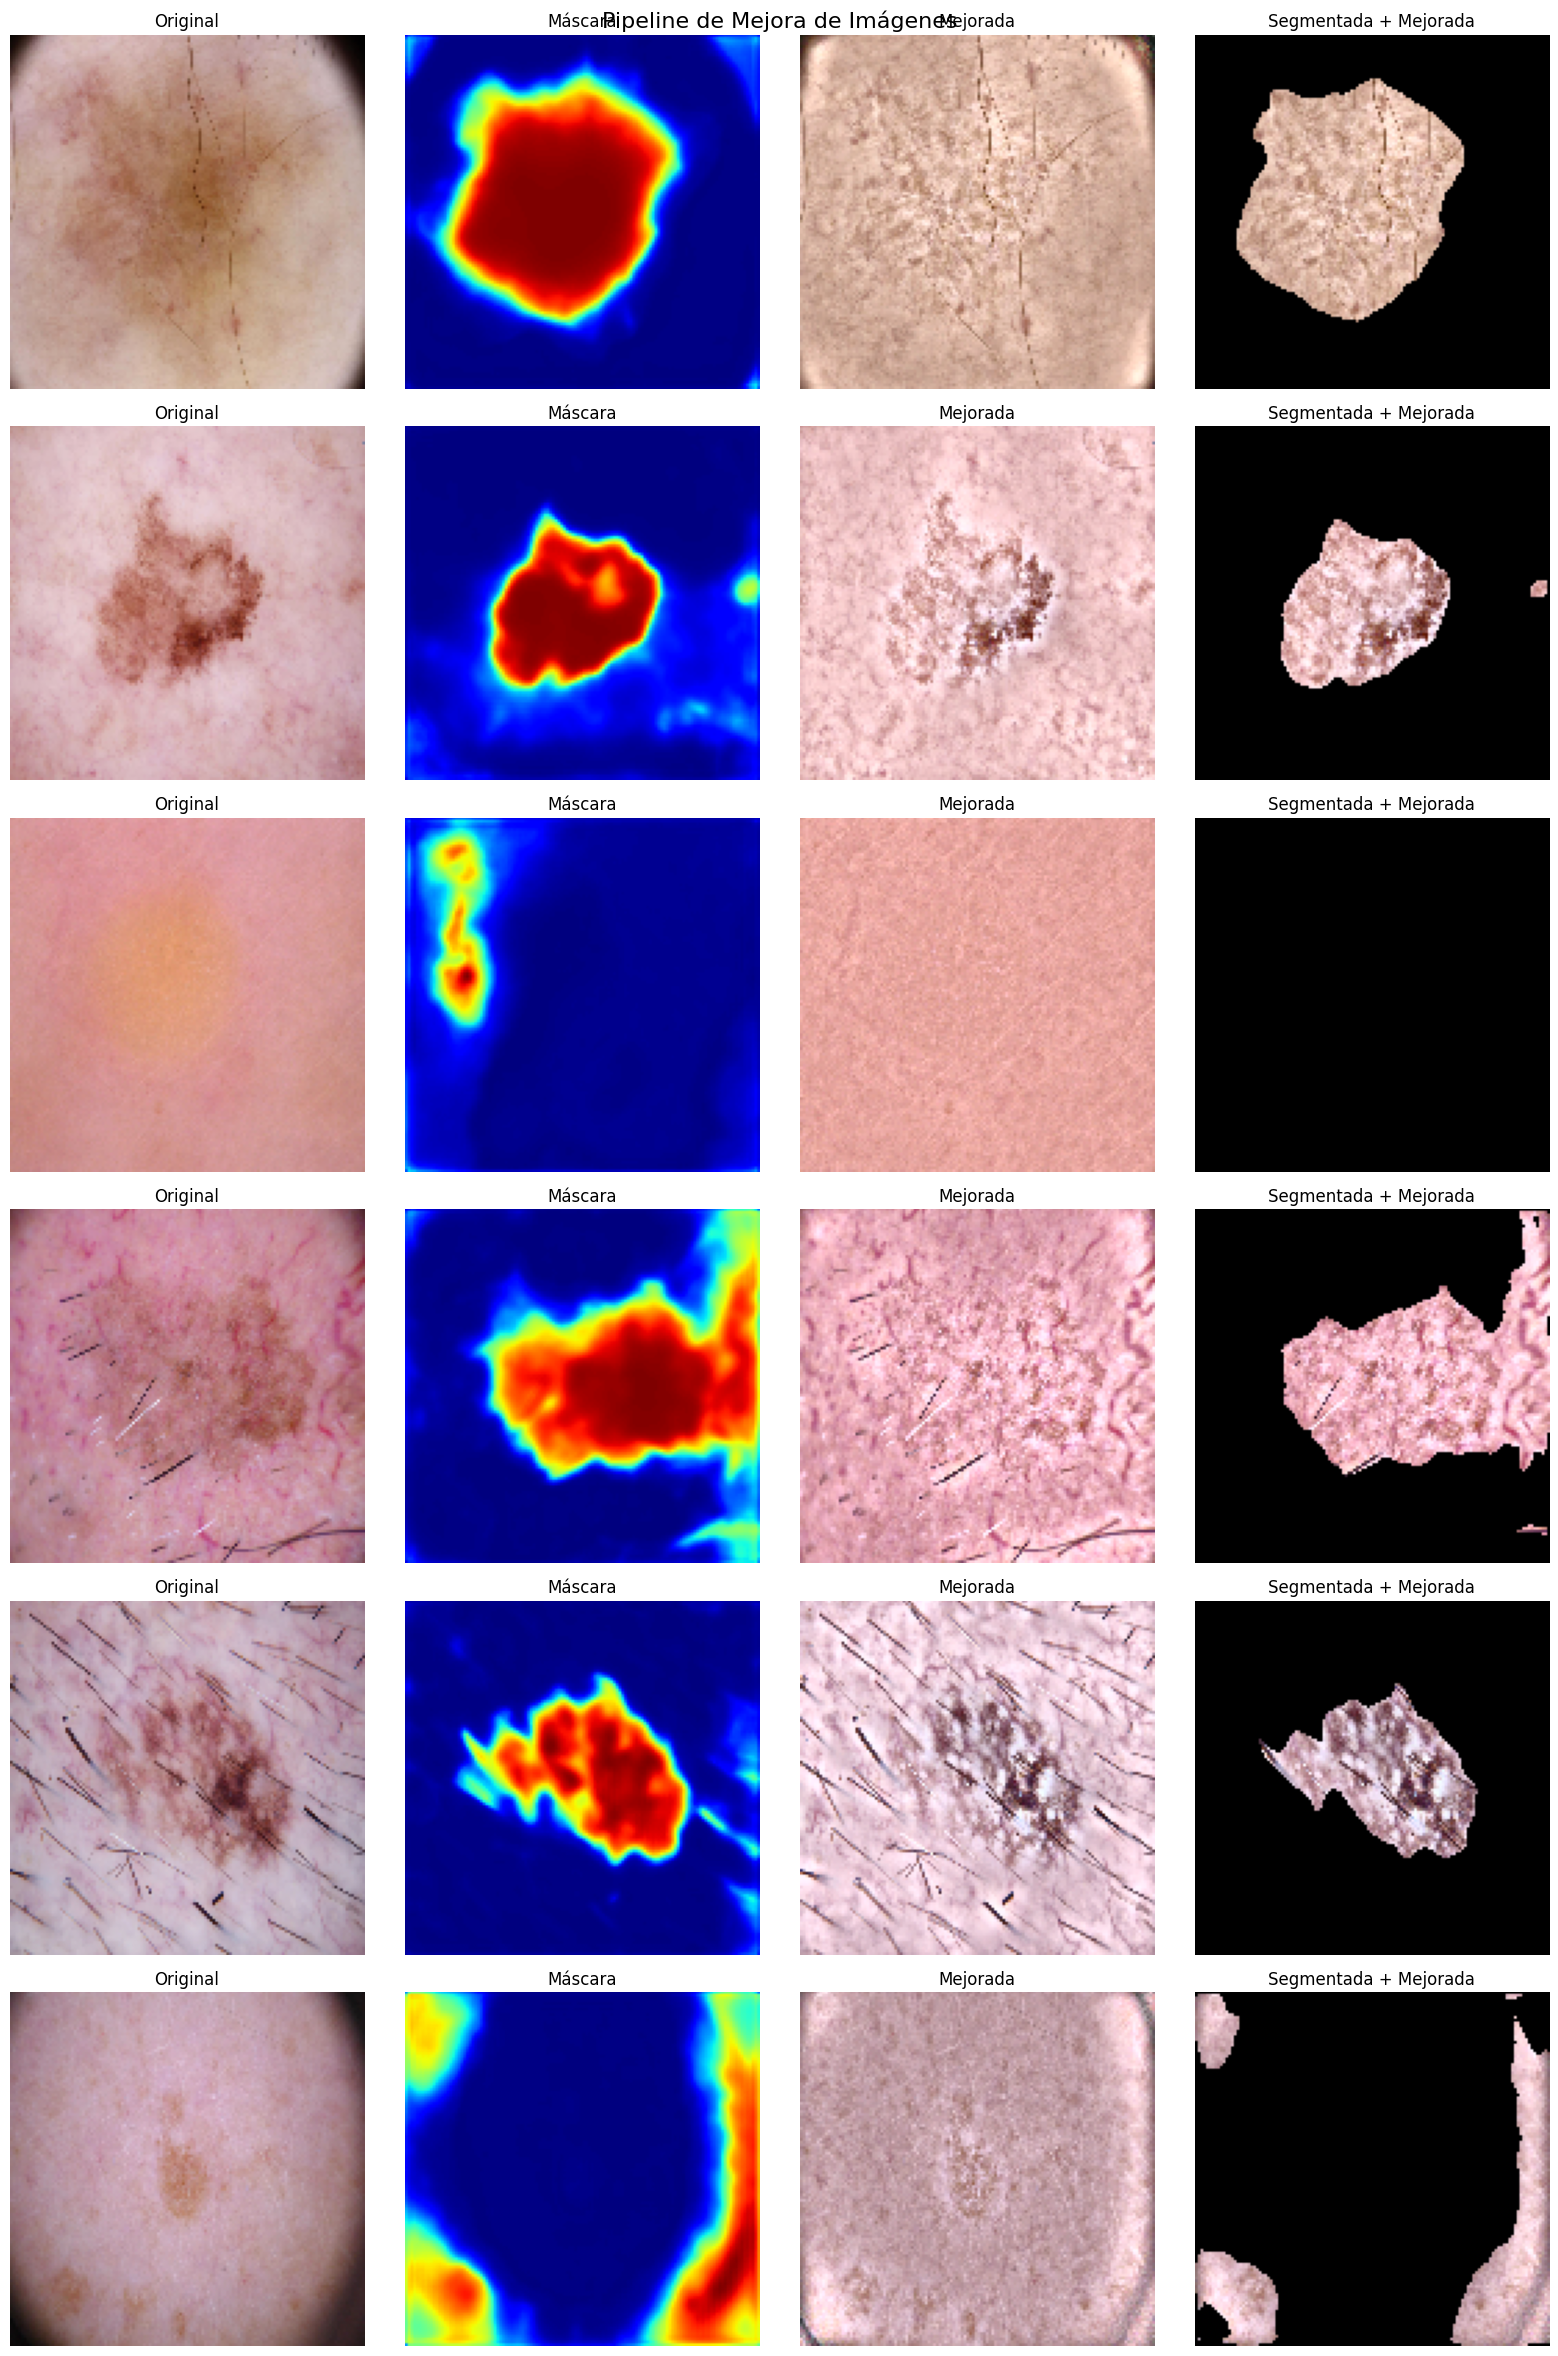

In [12]:
def full_enhancement_pipeline(img_path, model, size=128):
    """
    Pipeline completo de mejora de imagen.
    
    Args:
        img_path: Ruta a la imagen
        model: Modelo U-Net entrenado
        size: Tamaño de la imagen
    
    Returns:
        original: Imagen original
        mask: Máscara de segmentación
        enhanced: Imagen mejorada
        segmented: Imagen segmentada y mejorada
    """
    # Cargar imagen
    original = load_image(img_path, size)
    
    # Predecir máscara
    img_norm = original / 255.0
    img_batch = np.expand_dims(img_norm, axis=0)
    mask = model.predict(img_batch, verbose=0)[0].squeeze()
    mask_binary = (mask > 0.5).astype(np.float32)
    
    # Mejorar imagen
    enhanced = enhance_image(original)
    
    # Aplicar máscara
    segmented = enhanced * np.expand_dims(mask_binary, axis=-1)
    
    return original, mask, enhanced, segmented.astype(np.uint8)


# Demostración con imágenes de prueba
test_images = glob(os.path.join(TEST_DIR, '*', '*.jpg'))[:6]

fig, axes = plt.subplots(len(test_images), 4, figsize=(16, 4*len(test_images)))

for i, img_path in enumerate(test_images):
    original, mask, enhanced, segmented = full_enhancement_pipeline(img_path, model)
    
    axes[i, 0].imshow(original)
    axes[i, 0].set_title('Original')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(mask, cmap='jet')
    axes[i, 1].set_title('Máscara')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(enhanced)
    axes[i, 2].set_title('Mejorada')
    axes[i, 2].axis('off')
    
    axes[i, 3].imshow(segmented)
    axes[i, 3].set_title('Segmentada + Mejorada')
    axes[i, 3].axis('off')

plt.suptitle('Pipeline de Mejora de Imágenes', fontsize=16)
plt.tight_layout()
plt.show()

## 12. Guardar Modelo

In [13]:
# Guardar modelo
model.save('unet_segmentation_model.keras')
print("✅ Modelo guardado como 'unet_segmentation_model.keras'")

# Descargar desde Colab
try:
    from google.colab import files
    files.download('unet_segmentation_model.keras')
    print("📥 Descarga iniciada...")
except:
    print("⚠️ No se pudo iniciar la descarga automática.")
    print("   Por favor, descarga manualmente el archivo 'unet_segmentation_model.keras'")

✅ Modelo guardado como 'unet_segmentation_model.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Descarga iniciada...


## 13. Evaluación Final

In [14]:
# Evaluar en datos de validación
results = model.evaluate(X_val, Y_val, verbose=0)

print("\n" + "="*50)
print("📊 RESULTADOS FINALES")
print("="*50)
print(f"   Pérdida: {results[0]:.4f}")
print(f"   Precisión: {results[1]:.4f}")
print(f"   Coeficiente Dice: {results[2]:.4f}")
print("="*50)

print("\n✨ ¡Entrenamiento completado!")
print("\n📝 Próximos pasos:")
print("   1. Descargar 'unet_segmentation_model.keras'")
print("   2. Colocar en la carpeta 'models/' de tu proyecto")
print("   3. El servidor Flask cargará automáticamente el modelo")


📊 RESULTADOS FINALES
   Pérdida: 0.2469
   Precisión: 0.8981
   Coeficiente Dice: 0.7120

✨ ¡Entrenamiento completado!

📝 Próximos pasos:
   1. Descargar 'unet_segmentation_model.keras'
   2. Colocar en la carpeta 'models/' de tu proyecto
   3. El servidor Flask cargará automáticamente el modelo
